In [2]:
#importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
print("done")

done


### Import CSV File into dataframe

In [3]:
df = pd.read_csv('stud.csv')

### First 5 records

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Shape of the dataset

In [5]:
df.shape

(1000, 8)

### Dataset Information

##### gender : sex of students -> (Male/female)
##### race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
##### parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
##### lunch : having lunch before test (standard or free/reduced)
##### test preparation course : complete or not complete before test
##### math score
##### reading score
##### writing score

### Data Checks to perform

##### • Check Missing values
##### • Check Duplicates
##### • check data types
##### • check the number of unique values of each column 
##### • check statistics of data set
##### • check various categories present in the different categorical column

In [6]:
#Check Missing values
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

##### There is no missing values

In [7]:
#Check duplicates
df.duplicated().sum()

np.int64(0)

##### There is no duplicates values

In [8]:
#Check data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [9]:
#Check the number of unique values of each column 
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [10]:
#Check statistics of dataset
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insights
   ##### From the above description of numerical data, all means are very close to each other - between 66 and 68.05;
   ##### All standard deviations are also close between 14.6 and 15.19;
   ##### While there is a minimum score 0 for math, for writing minimum is much higher =  10 and for reading min = 17

In [11]:
#Exploring data
print("Categories in 'gender' variable: ",end=" ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable: ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in 'parental level of education' variable: ",end=" ")
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable: ",end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable: ",end=" ")
print(df['test_preparation_course'].unique())


Categories in 'gender' variable:  <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race/ethnicity' variable:  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental level of education' variable:  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:  <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [12]:
#Define numerical and categorical columns
numeric_feature = [feature for feature in df.columns if df[feature].dtype != 'string']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'string']

print("We have {} numerical features : {}".format(len(numeric_feature),numeric_feature))
print("\nWe have {} categorical_features : {}".format(len(categorical_features),categorical_features))

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']

We have 5 categorical_features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [13]:
#Adding column "Total Score" and "Average"
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total_score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [14]:
reading_full = df[df['reading_score']==100]['average'].count()
writing_full = df[df['writing_score']==100]['average'].count()
math_full = df[df['math_score']==100]['average'].count()

print(f"Number of student with full marks in math : {math_full}")
print(f"Number of student with full marks in reading : {reading_full}")
print(f"Number of student with full marks in writing : {writing_full}")

Number of student with full marks in math : 7
Number of student with full marks in reading : 17
Number of student with full marks in writing : 14


In [15]:
reading_less_20 = df[df['reading_score']<=20]['average'].count()
writing_less_20  = df[df['writing_score']<=20]['average'].count()
math_less_20  = df[df['math_score']<=20]['average'].count()

print(f"Number of student with less than 20 marks in math : {math_less_20}")
print(f"Number of student with less than 20 marks in reading : {reading_less_20}")
print(f"Number of student with less than 20 marks in writing : {writing_less_20}")

Number of student with less than 20 marks in math : 4
Number of student with less than 20 marks in reading : 1
Number of student with less than 20 marks in writing : 3


##### From above values we got insight that student were performed worst in maths.
##### And the best performance is reading section.

### Exploratory Data (Visualization)

##### Visulaizing average score distribution to make some conclusion
##### Histogram and KDE

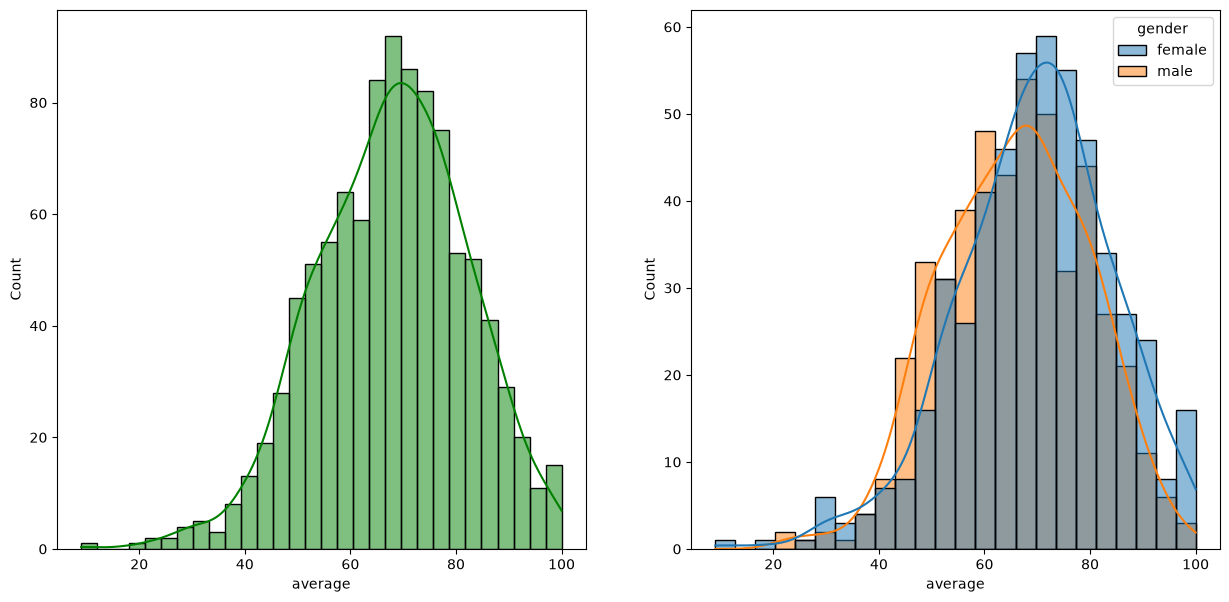

In [16]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x = 'average',bins = 30, kde = True,color = 'g')
plt.subplot(122)
sns.histplot(data=df,x = 'average',kde = True,hue ='gender')
plt.show()

####

##### Insights
##### • Female students tend to perform well then male students

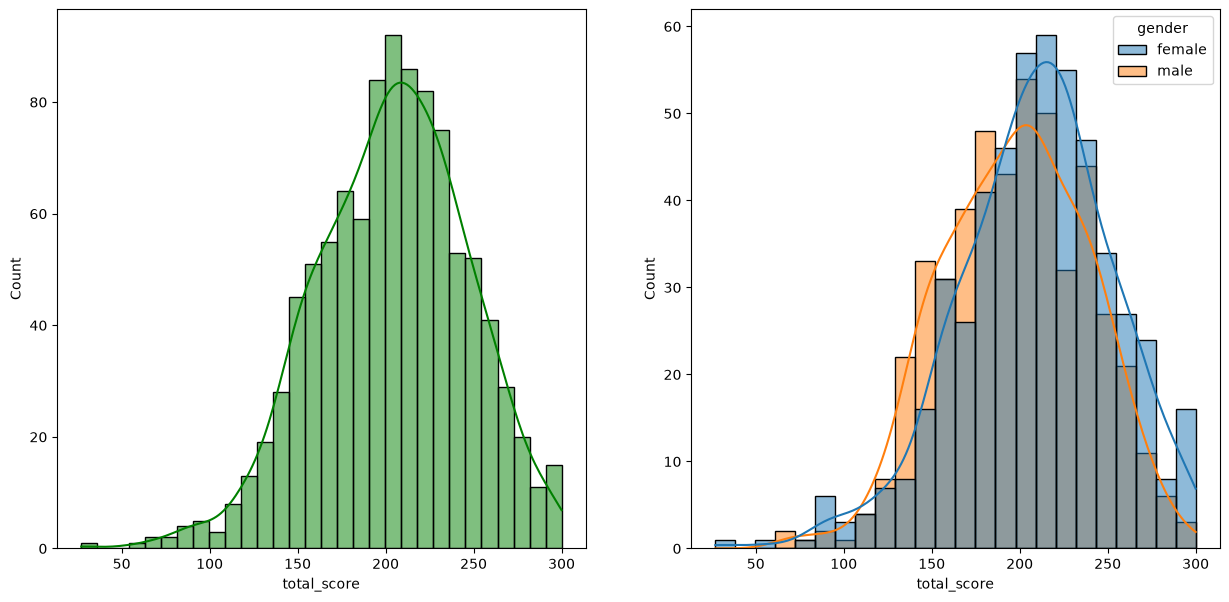

In [17]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x = 'total_score',bins = 30, kde = True,color = 'g')
plt.subplot(122)
sns.histplot(data=df,x = 'total_score',kde = True,hue ='gender')
plt.show()

##### Insights
##### • Female students tend to perform well then male students

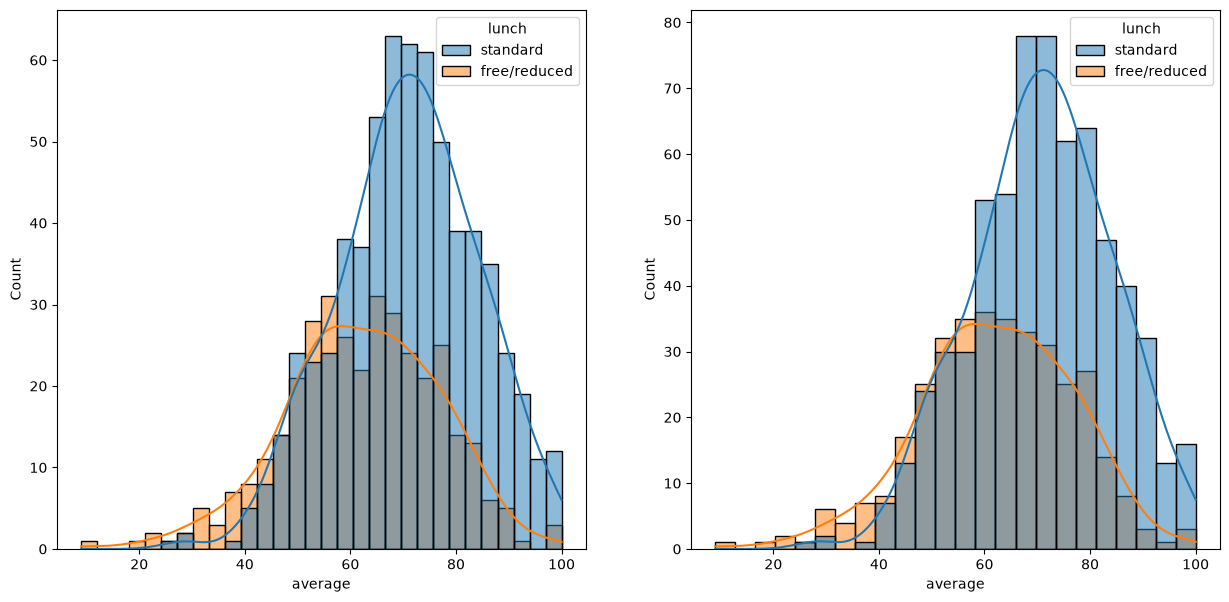

In [18]:
fig, axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x = 'average',bins = 30, hue='lunch', kde = True,color = 'g')
plt.subplot(122)
sns.histplot(data=df,x = 'average',kde = True,hue ='lunch')
plt.show()

##### Insights
##### • Standard lunch helps students perform well.

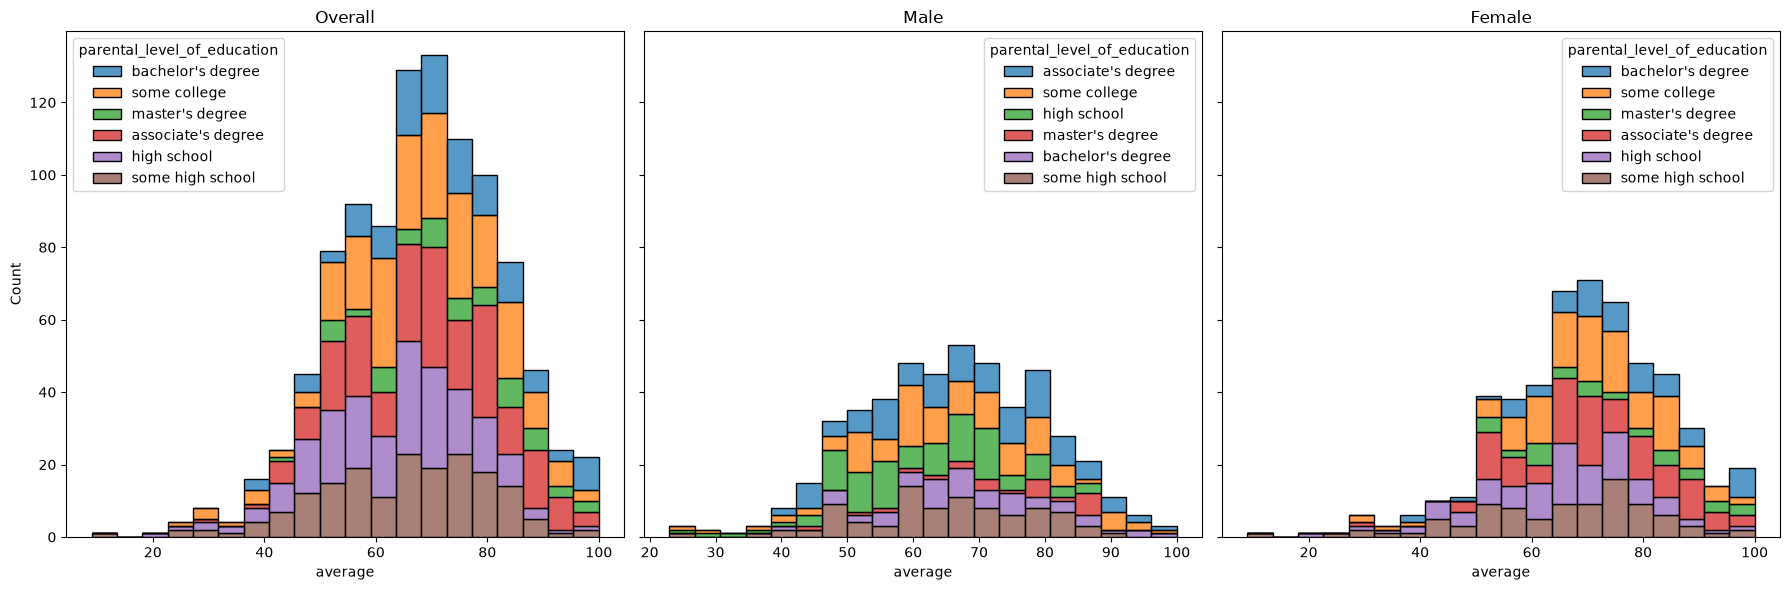

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

sns.histplot(
    data=df,
    x="average",
    hue="parental_level_of_education",
    bins=20,
    multiple="stack",
    kde=False,
    ax=axs[0]
)
axs[0].set_title("Overall")

sns.histplot(
    data=df[df.gender=="male"],
    x="average",
    hue="parental_level_of_education",
    bins=20,
    multiple="stack",
    kde=False,
    ax=axs[1]
)
axs[1].set_title("Male")

sns.histplot(
    data=df[df.gender=="female"],
    x="average",
    hue="parental_level_of_education",
    bins=20,
    multiple="stack",
    kde=False,
    ax=axs[2]
)
axs[2].set_title("Female")

plt.tight_layout()
plt.show()

##### Insights
   ######         • In general parent's education don't help student perform well in exam.
   ######    • 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
   ###### • 3rd plot shows that there is no effect of parent's education on female students      

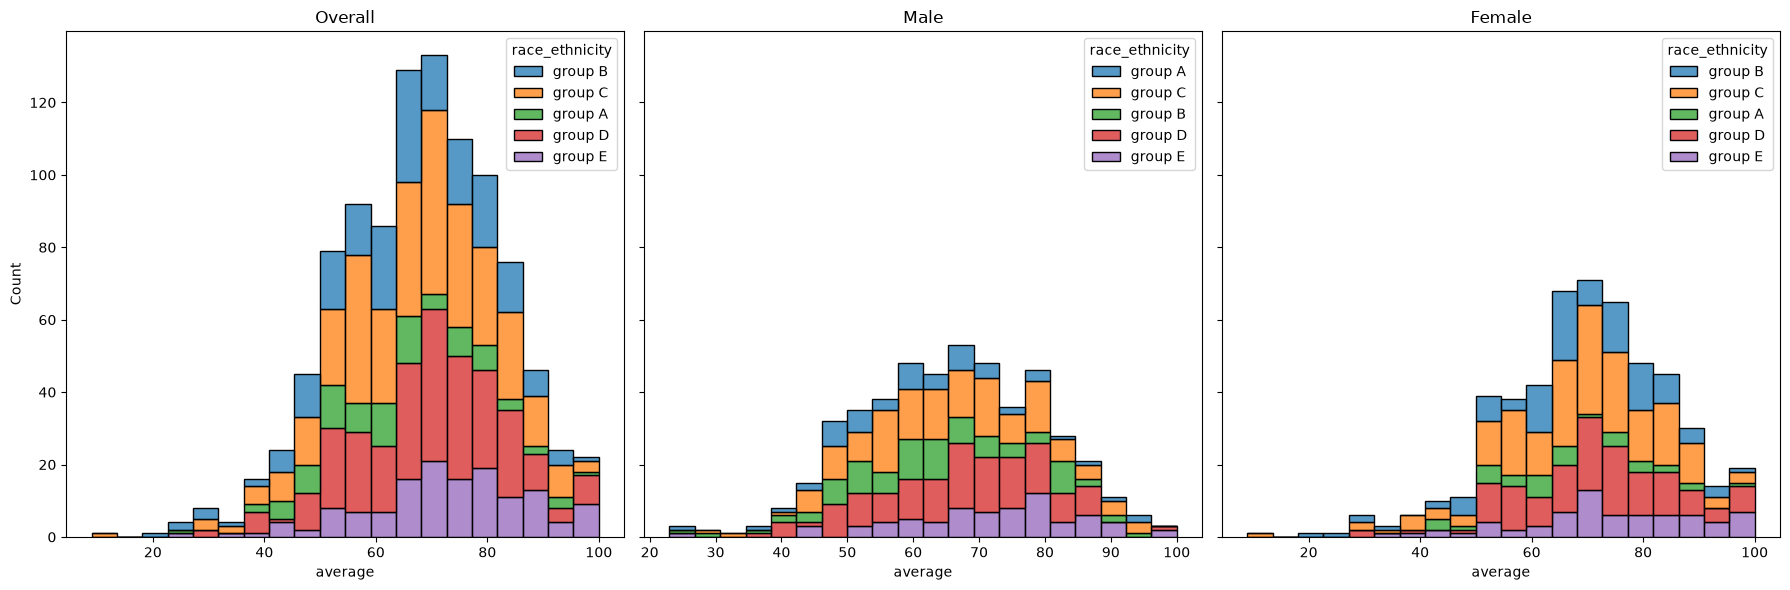

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

sns.histplot(
    data=df,
    x="average",
    hue="race_ethnicity",
    bins=20,
    multiple="stack",
    kde=False,
    ax=axs[0]
)
axs[0].set_title("Overall")

sns.histplot(
    data=df[df.gender=="male"],
    x="average",
    hue="race_ethnicity",
    bins=20,
    multiple="stack",
    kde=False,
    ax=axs[1]
)
axs[1].set_title("Male")

sns.histplot(
    data=df[df.gender=="female"],
    x="average",
    hue="race_ethnicity",
    bins=20,
    multiple="stack",
    kde=False,
    ax=axs[2]
)
axs[2].set_title("Female")

plt.tight_layout()
plt.show()

#### Insights
 ##### • Students from group A and B performs poorly in exam irrespective of their gender


<Axes: title={'center': 'WRITING SCORE'}, ylabel='writing_score'>

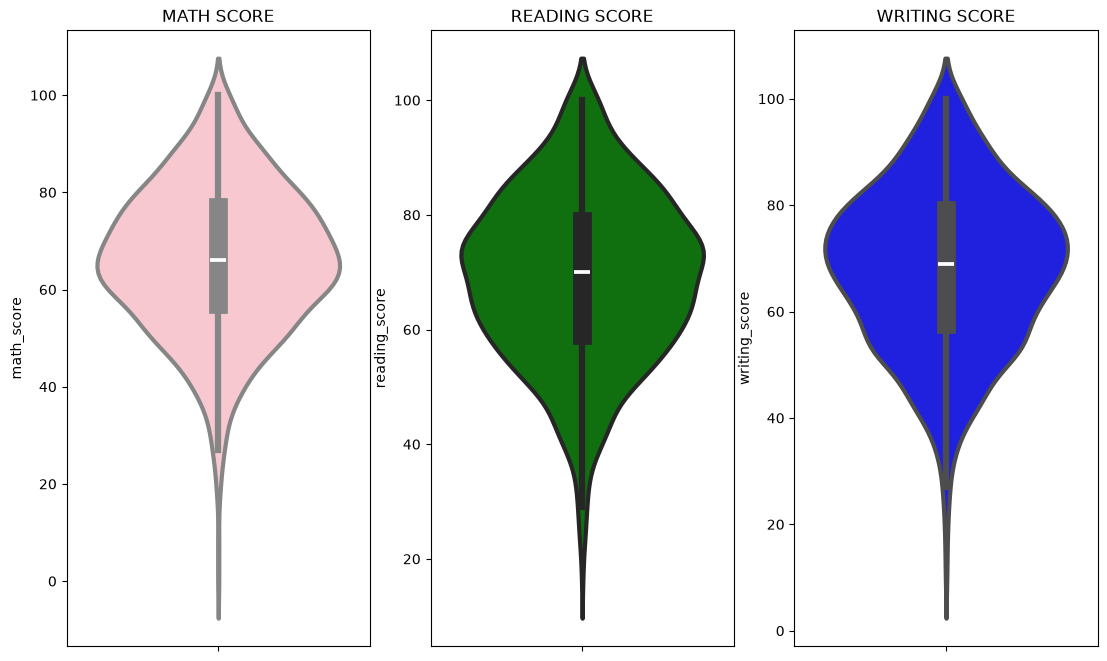

In [21]:
plt.figure(figsize=(18,8))
plt.subplot(1,4,1)
plt.title('MATH SCORE')
sns.violinplot(y='math_score',data=df,color='pink',linewidth=3)
plt.subplot(1,4,2)
plt.title('READING SCORE')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1,4,3)
plt.title('WRITING SCORE')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)


#### Insights 
  ##### • From the above three plots its clearly visible that most of the student score between 60-80 in Maths whereas in reading and writing most of them score from 50-80

#### 4.3 Multivariate Analysis

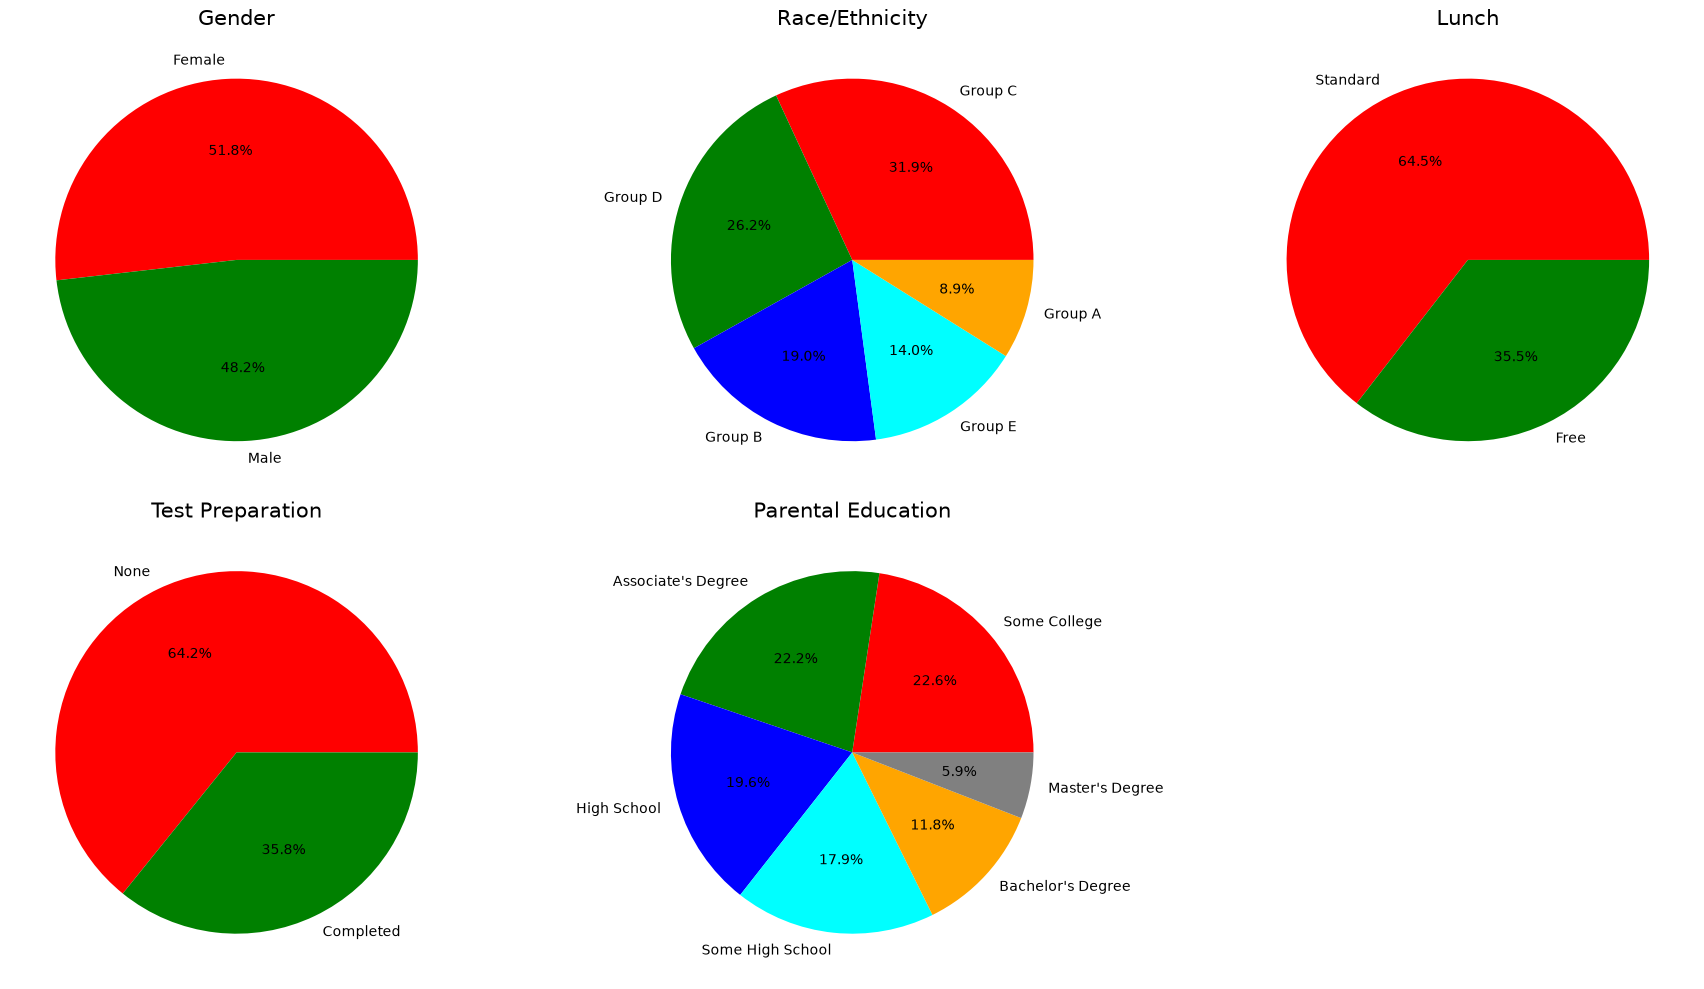

In [25]:
plt.figure(figsize=(18, 10))

# 1
plt.subplot(2,3,1)
size = df['gender'].value_counts()
labels = ['Female', 'Male']
colors = ['red', 'green']
plt.pie(size, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Gender', fontsize=15)

# 2
plt.subplot(2,3,2)
size = df['race_ethnicity'].value_counts()
labels = ['Group C', 'Group D', 'Group B', 'Group E', 'Group A']
colors = ['red', 'green', 'blue', 'cyan', 'orange']
plt.pie(size, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Race/Ethnicity', fontsize=15)

# 3
plt.subplot(2,3,3)
size = df['lunch'].value_counts()
labels = ['Standard', 'Free']
colors = ['red', 'green']
plt.pie(size, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Lunch', fontsize=15)

# 4
plt.subplot(2,3,4)
size = df['test_preparation_course'].value_counts()
labels = ['None', 'Completed']
colors = ['red', 'green']
plt.pie(size, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Test Preparation', fontsize=15)

# 5
plt.subplot(2,3,5)
size = df['parental_level_of_education'].value_counts()
labels = [
    'Some College',
    "Associate's Degree",
    'High School',
    'Some High School',
    "Bachelor's Degree",
    "Master's Degree"
]
colors = ['red', 'green', 'blue', 'cyan', 'orange', 'grey']
plt.pie(size, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Parental Education', fontsize=15)

plt.tight_layout()
plt.show()


#### Insights
##### • Number of male and female students is almost same 
##### • Number of students are greatest in Group C
##### • Number of students who have standard lunch are greater
##### • Number of students who have not enrolled in any test preparation course is greater 
##### • Number of students whose parental education is 'Some College is greater followed by closely by "Associate's Degree"


#### 4.4 Feature wise Visualization 

##### 4.4.1 UNIVARIATE ANALYSIS (Gender column distribution)

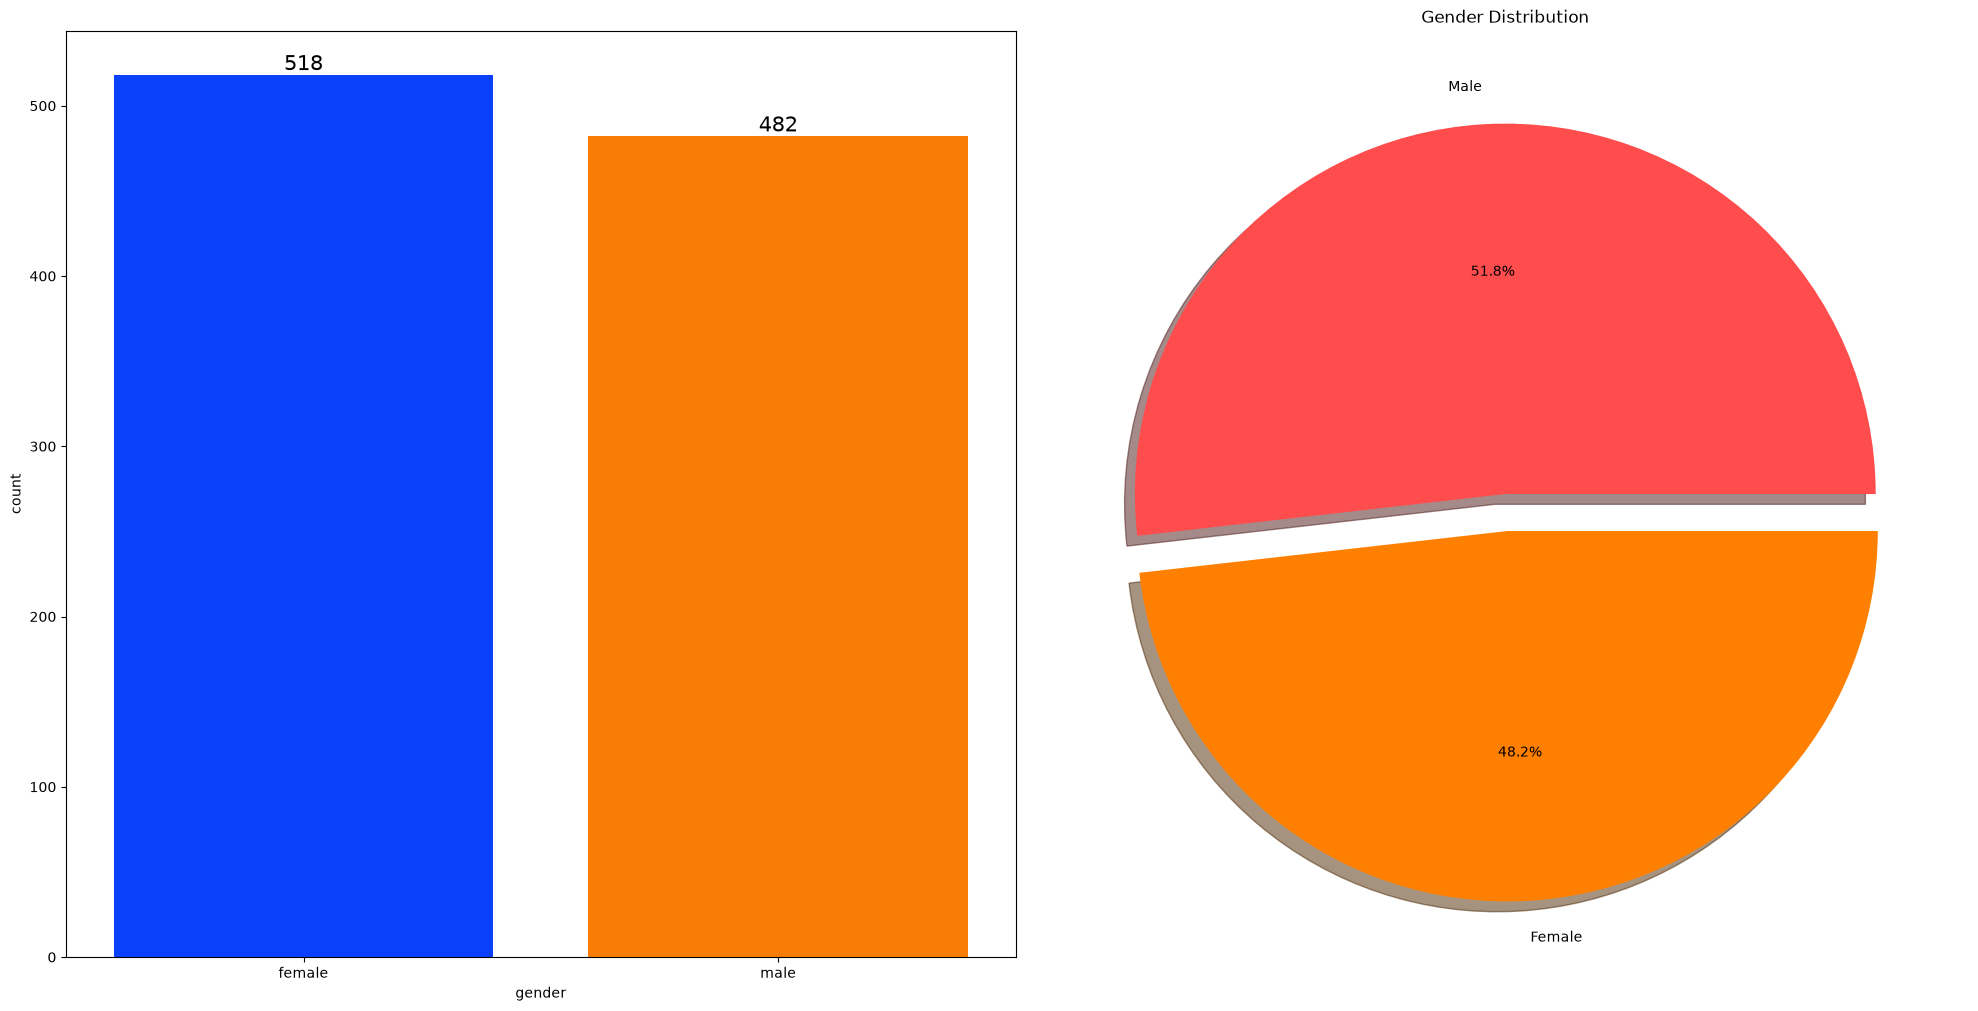

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

sns.countplot(
    x=df['gender'],
    data=df,
    palette='bright',
    ax=ax[0],
    saturation=0.95
)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=15)

ax[1].pie(
    x=df['gender'].value_counts(),
    labels=['Male', 'Female'],
    explode=[0, 0.1],          # Only 2 categories, so only 2 values
    autopct='%1.1f%%',
    shadow=True,
    colors=['#ff4d4d', '#ff8000']
)
ax[1].set_title("Gender Distribution")

plt.tight_layout()
plt.show()

#### **Insights** 
 ##### • Gender column has balanced data with female students are 518 and male students are 482

##### **BIVARIATE ANALYSIS (Is Gender has any impact on student's performance ?)**

In [33]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math_score,reading_score,writing_score,total_score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


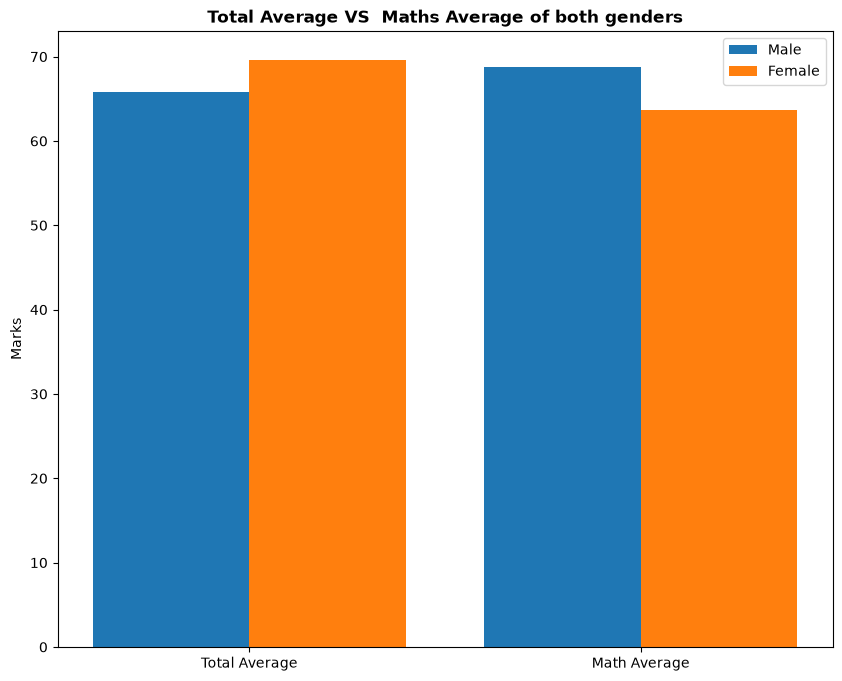

In [35]:
plt.figure(figsize=(10,8))
X=['Total Average','Math Average']

female_scores = [
    gender_group.loc['female', 'average'],
    gender_group.loc['female', 'math_score']
]
male_scores = [
    gender_group.loc['male', 'average'],
    gender_group.loc['male', 'math_score']
]

X_axis = np.arange(len(X))
plt.bar(X_axis-0.2,male_scores,0.4,label='Male')
plt.bar(X_axis+0.2,female_scores,0.4,label ='Female')

plt.xticks(X_axis,X)
plt.ylabel("Marks")
plt.title("Total Average VS  Maths Average of both genders",fontweight='bold')
plt.legend()
plt.show()

##### **Insights**
 ##### • On an average female have better overall score than men.
 ##### • Whereas males have scored higher in Maths

#### **4.4.2 RACE/EHNICITY COLUMN**


##### UNIVARIATE ANALYSIS (How is group wise distribution?)

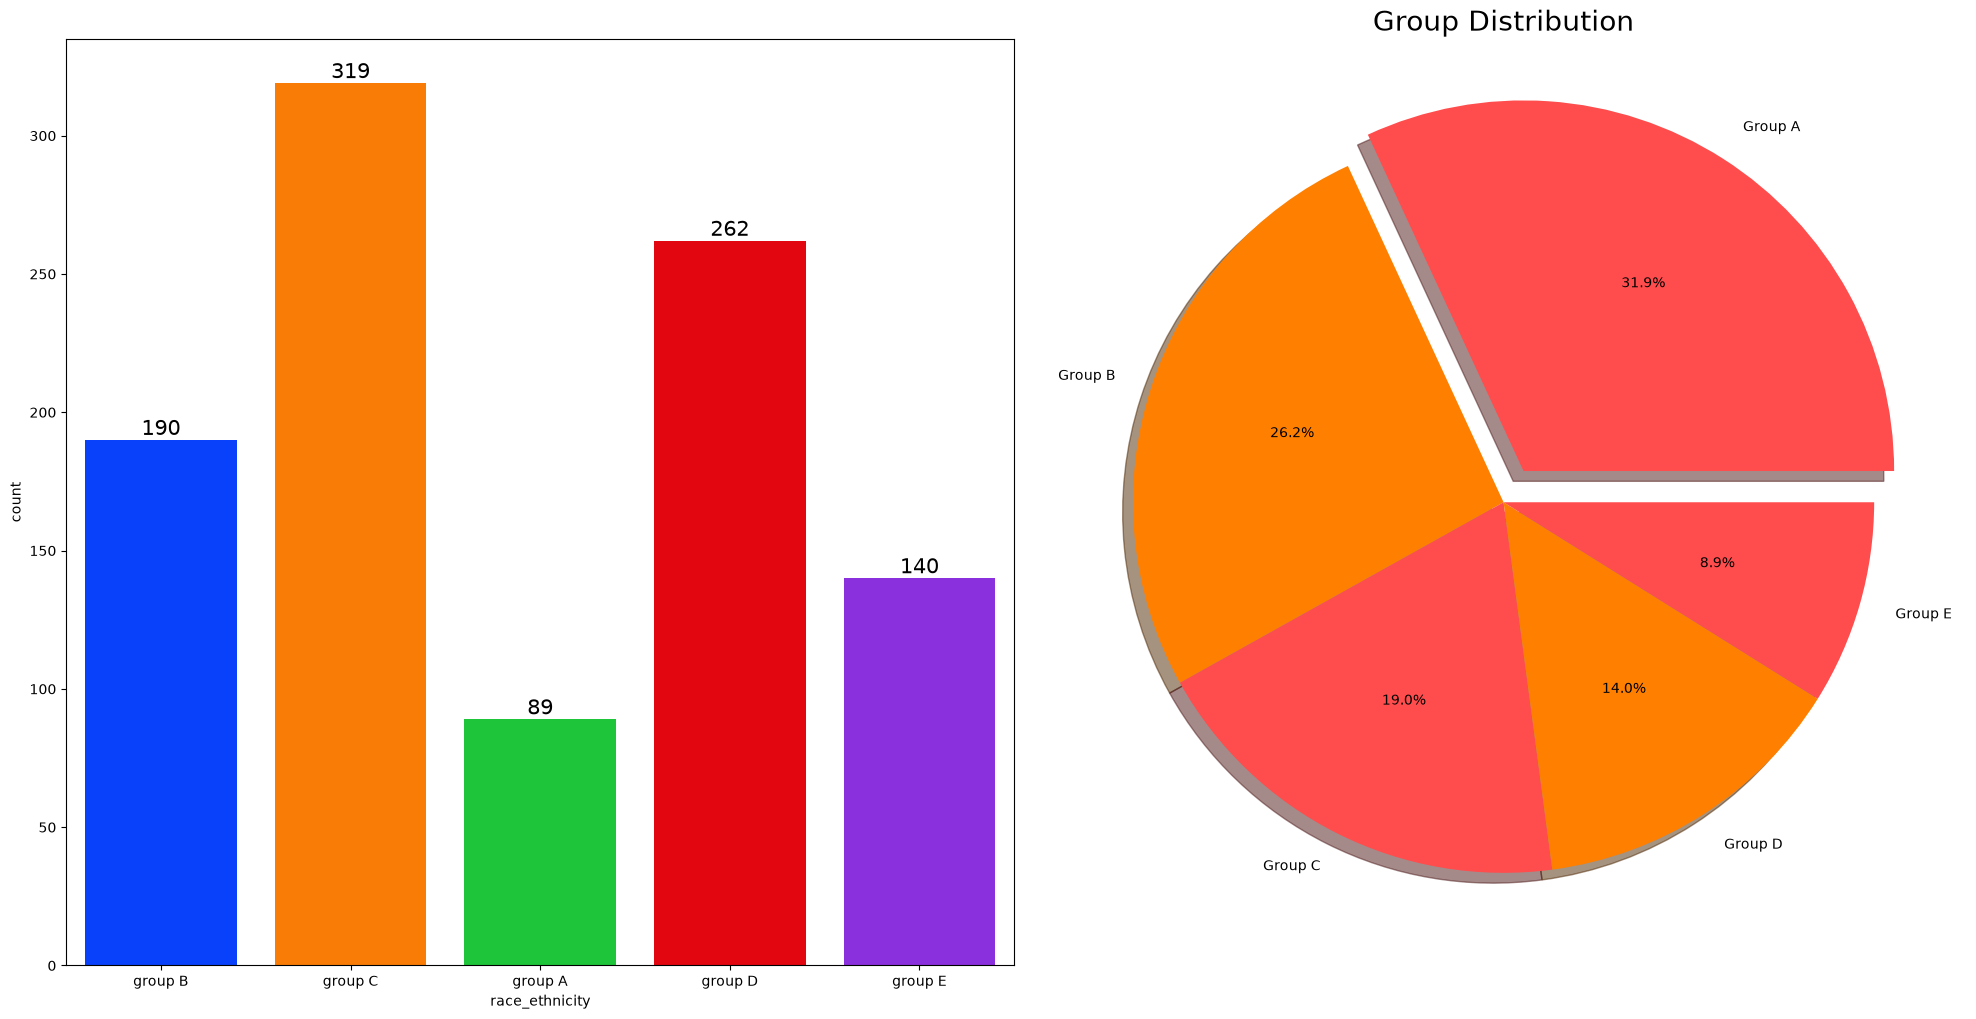

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

sns.countplot(
    x=df['race_ethnicity'],
    data=df,
    palette='bright',
    ax=ax[0],
    saturation=0.95
)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=15)

ax[1].pie(
    x=df['race_ethnicity'].value_counts(),
    labels=['Group A', 'Group B','Group C','Group D','Group E'],
    explode=[0.1,0,0,0,0],          # Only 2 categories, so only 2 values
    autopct='%1.1f%%',
    shadow=True,
    colors=['#ff4d4d', '#ff8000']
)
ax[1].set_title("Group Distribution" ,fontsize=20)

plt.tight_layout()
plt.show()

#### **Insights**
  ##### • Most of the students are from Group C and Group D
  ##### • Whereas Lowest number of students are from Group A

##### **BIVARIATE ANALYSIS( Is race/ethnicity has any impact on student's performance)**

In [42]:
race_group = df.groupby('race_ethnicity').mean(numeric_only=True)
race_group

,math_score,reading_score,writing_score,total_score,average
race_ethnicity,,,,,
group A,61.629213,64.674157,62.674157,188.977528,62.992509
group B,63.452632,67.352632,65.600000,196.405263,65.468421
group C,64.463950,69.103448,67.827586,201.394984,67.131661
group D,67.362595,70.030534,70.145038,207.538168,69.179389
group E,73.821429,73.028571,71.407143,218.257143,72.752381


Text(0, 0.5, 'Average Score')

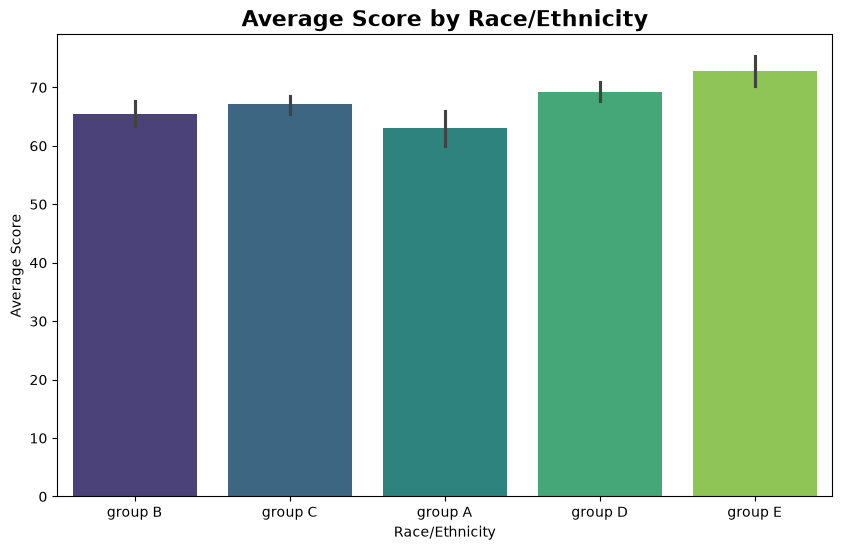

In [43]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='race_ethnicity',
    y='average',
    palette='viridis'
)

plt.title("Average Score by Race/Ethnicity", fontsize=16, fontweight='bold')
plt.xlabel("Race/Ethnicity")
plt.ylabel("Average Score")

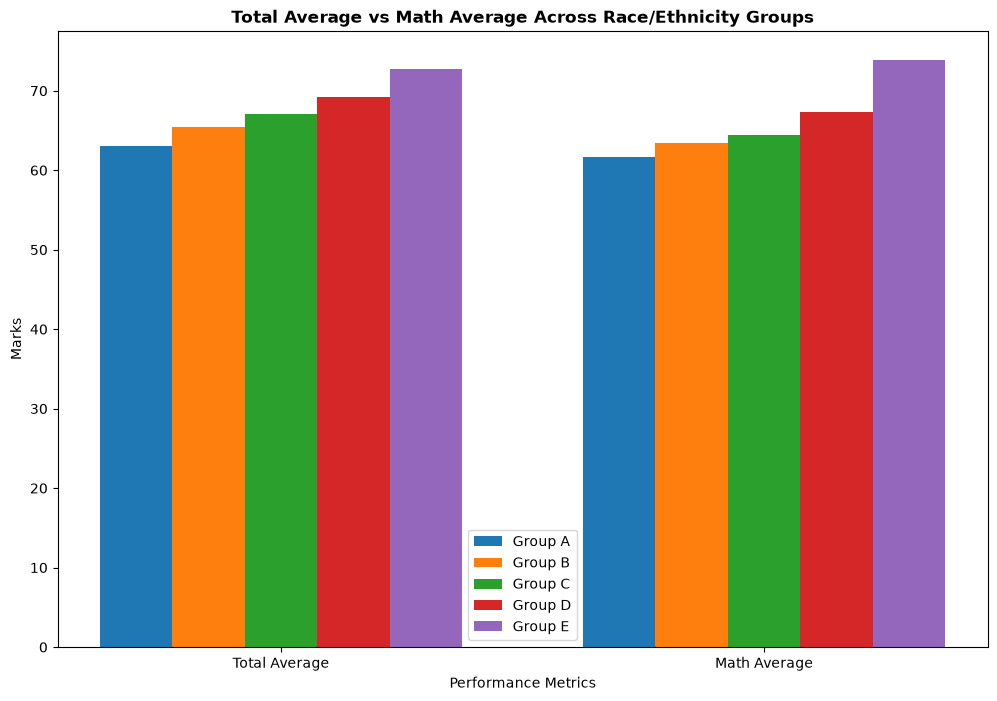

In [44]:
plt.figure(figsize=(12, 8))

X = ['Total Average', 'Math Average']

group_A = [
    race_group.loc['group A', 'average'],
    race_group.loc['group A', 'math_score']
]

group_B = [
    race_group.loc['group B', 'average'],
    race_group.loc['group B', 'math_score']
]

group_C = [
    race_group.loc['group C', 'average'],
    race_group.loc['group C', 'math_score']
]

group_D = [
    race_group.loc['group D', 'average'],
    race_group.loc['group D', 'math_score']
]

group_E = [
    race_group.loc['group E', 'average'],
    race_group.loc['group E', 'math_score']
]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.30, group_A, 0.15, label='Group A')
plt.bar(X_axis - 0.15, group_B, 0.15, label='Group B')
plt.bar(X_axis,        group_C, 0.15, label='Group C')
plt.bar(X_axis + 0.15, group_D, 0.15, label='Group D')
plt.bar(X_axis + 0.30, group_E, 0.15, label='Group E')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.xlabel("Performance Metrics")
plt.title("Total Average vs Math Average Across Race/Ethnicity Groups",
          fontweight='bold')
plt.legend()

plt.show()

#### **Insights**
##### • Group E students have scored the highest  marks  • Group A scored the lowest marks
##### 


#### 4.4.3 PARENTAL LEVEL OF EDUCATION 



##### UNIVARIATE ANALYSIS (What is the educational background of student's parents)

findfont: Failed to find font weight 30, now using 400.


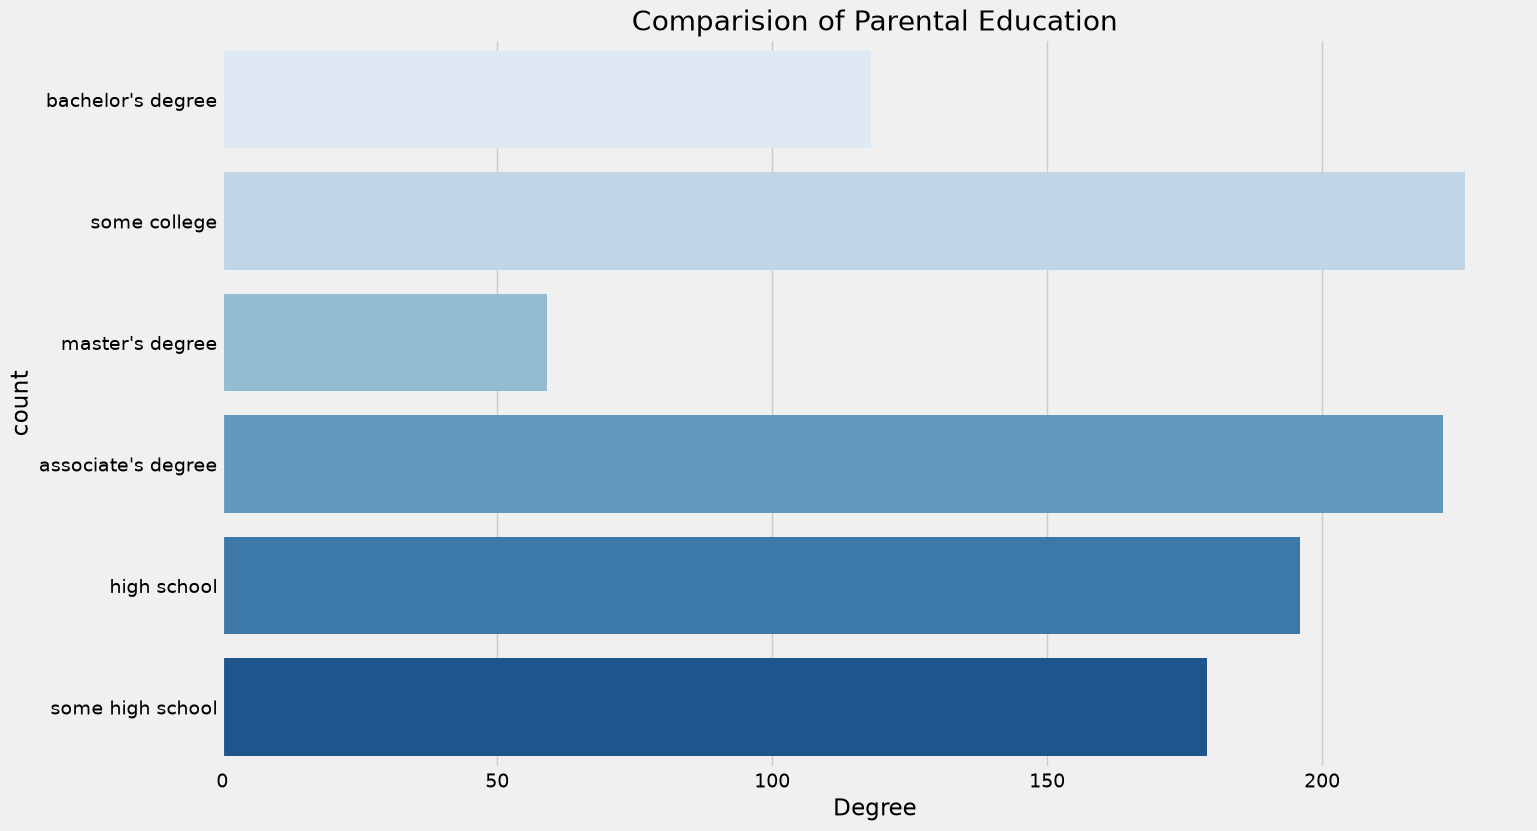

In [45]:
plt.rcParams['figure.figsize'] = (15,9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'],palette='Blues')
plt.title('Comparision of Parental Education',fontweight=30,fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

#### **Insights**
###### **• Largest number of parents are from some colleges**

##### **BIVARIATE ANALYSIS (Is parental education has any impact on student's performance)**

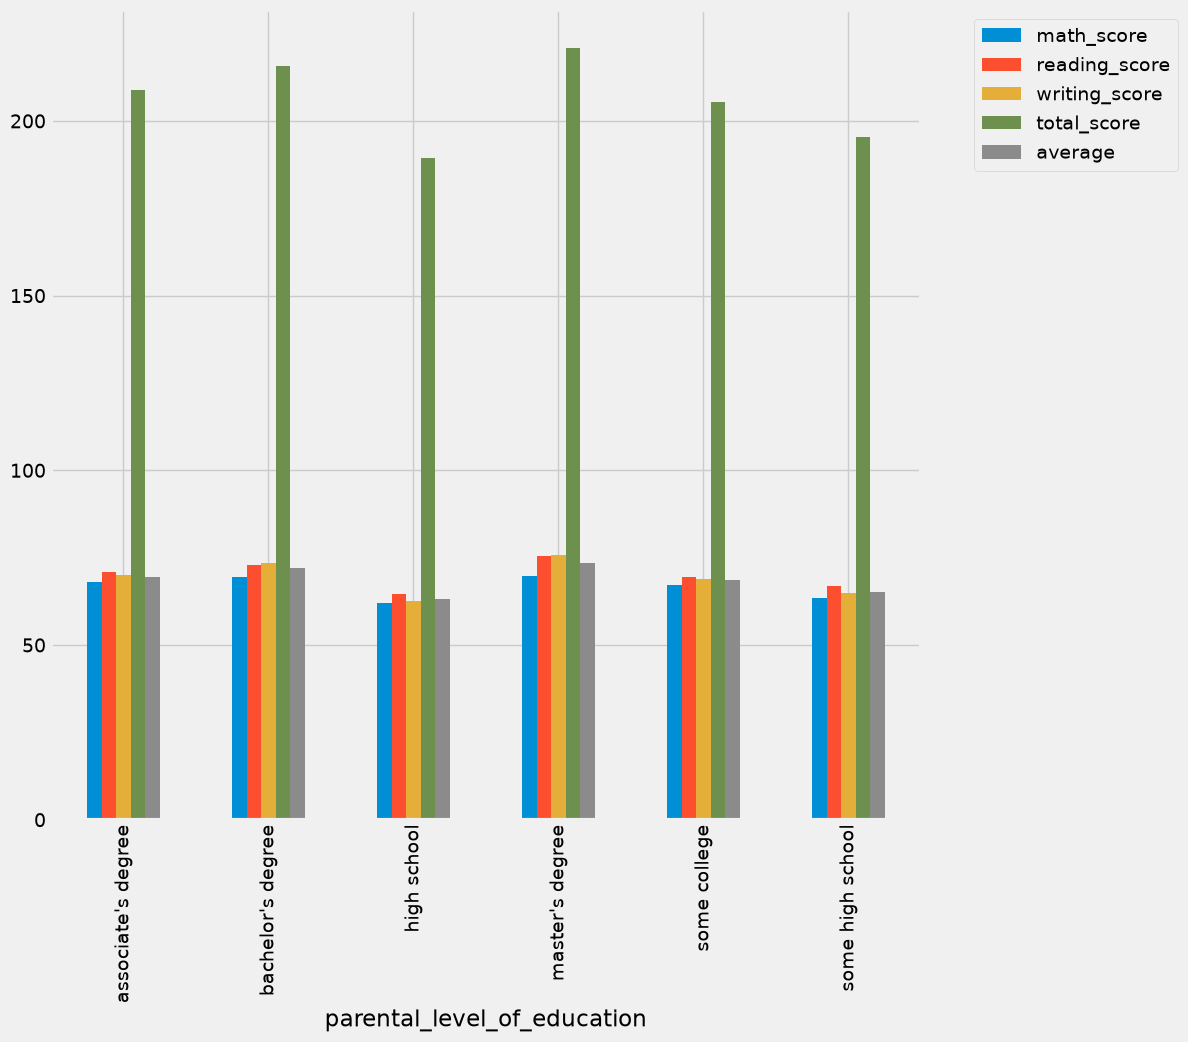

In [50]:
df.groupby('parental_level_of_education').mean(numeric_only=True).plot(kind='bar',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

#### **Insights**  
• The score of student whose parents possess master and bachelor level of education are higher than others.


#### **4.4.4 LUNCH COLUMN**

##### **UNIVARIATE ANALYSIS (Which type of lunch is most common amoung students ?)**

findfont: Failed to find font weight 30, now using 400.


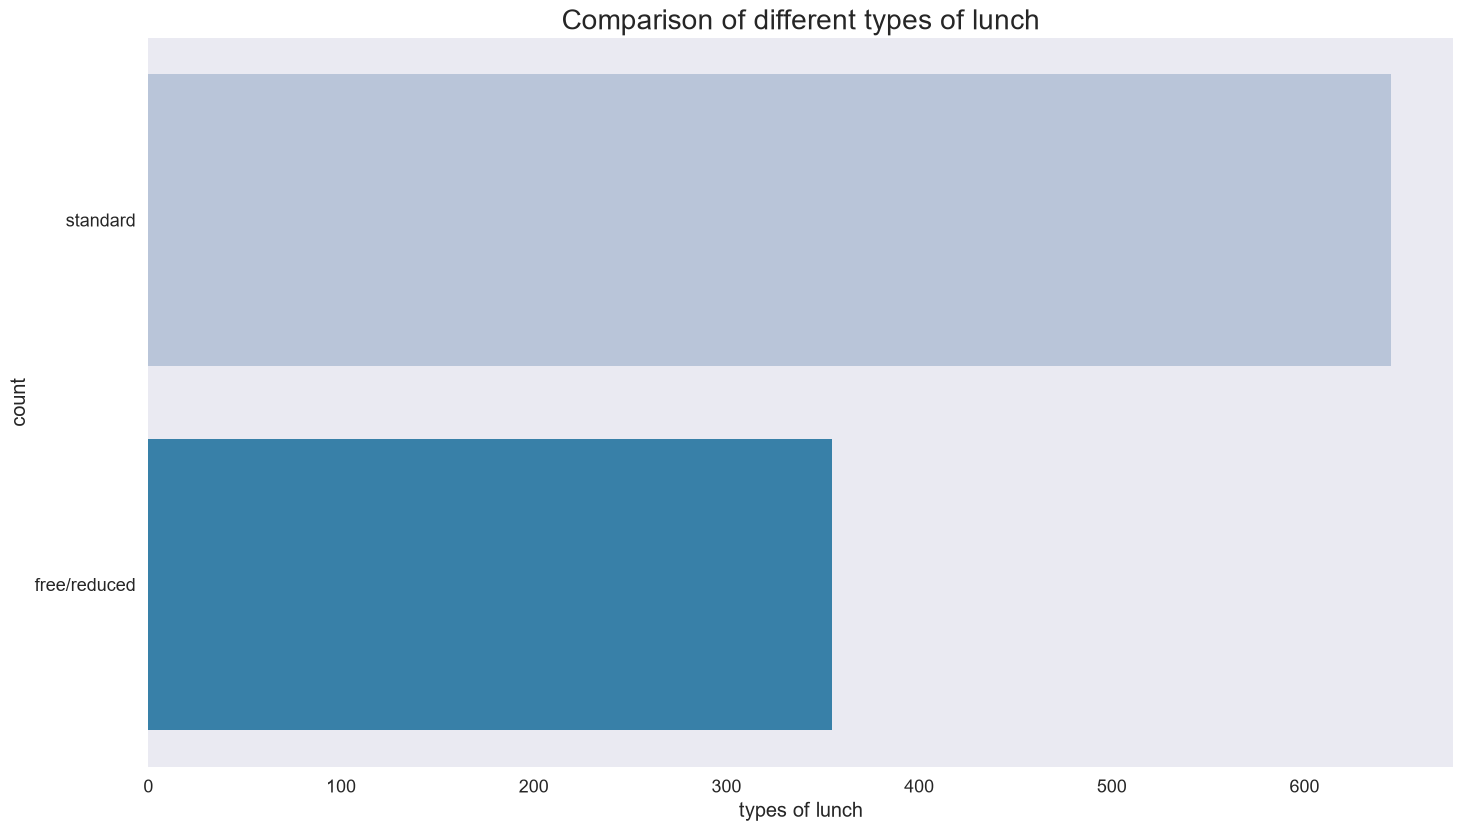

In [54]:

plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-dark')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

#### **Insights**
###### • Students being served Standard lunch was more than free lunch

##### **BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )**

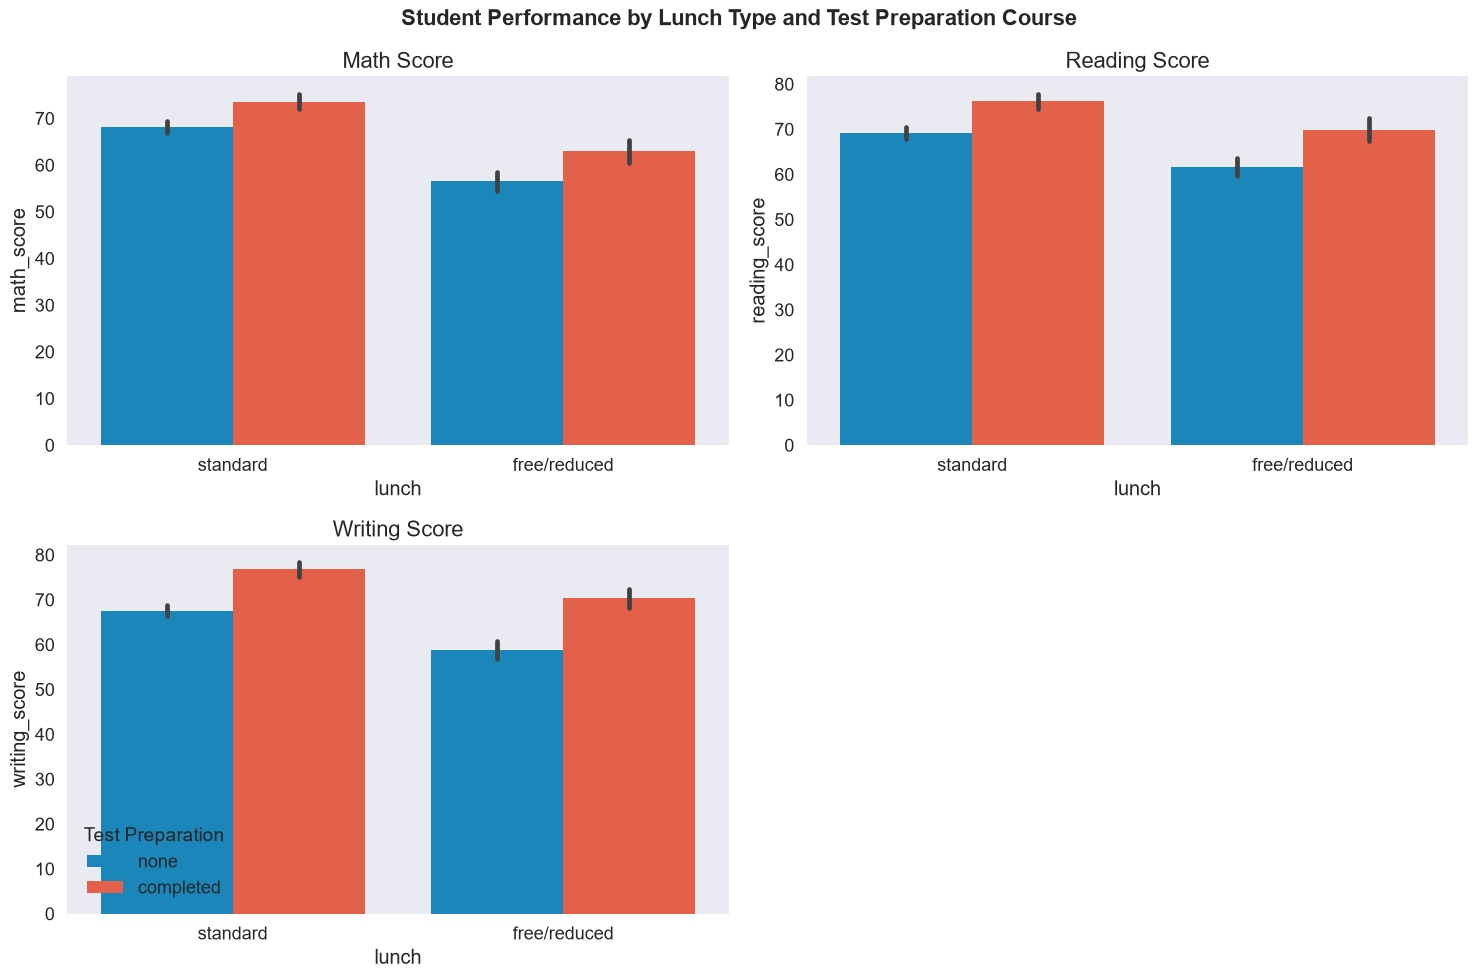

In [56]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# Math Score
sns.barplot(
    data=df,
    x='lunch',
    y='math_score',
    hue='test_preparation_course',
    ax=ax[0, 0]
)
ax[0, 0].set_title("Math Score")
ax[0, 0].legend_.remove()

# Reading Score
sns.barplot(
    data=df,
    x='lunch',
    y='reading_score',
    hue='test_preparation_course',
    ax=ax[0, 1]
)
ax[0, 1].set_title("Reading Score")
ax[0, 1].legend_.remove()

# Writing Score
sns.barplot(
    data=df,
    x='lunch',
    y='writing_score',
    hue='test_preparation_course',
    ax=ax[1, 0]
)
ax[1, 0].set_title("Writing Score")
ax[1, 0].legend(title="Test Preparation")

# Remove the empty subplot
fig.delaxes(ax[1, 1])

plt.suptitle(
    "Student Performance by Lunch Type and Test Preparation Course",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

#### **Insights**
###### • Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

#### **Checking Outliers**

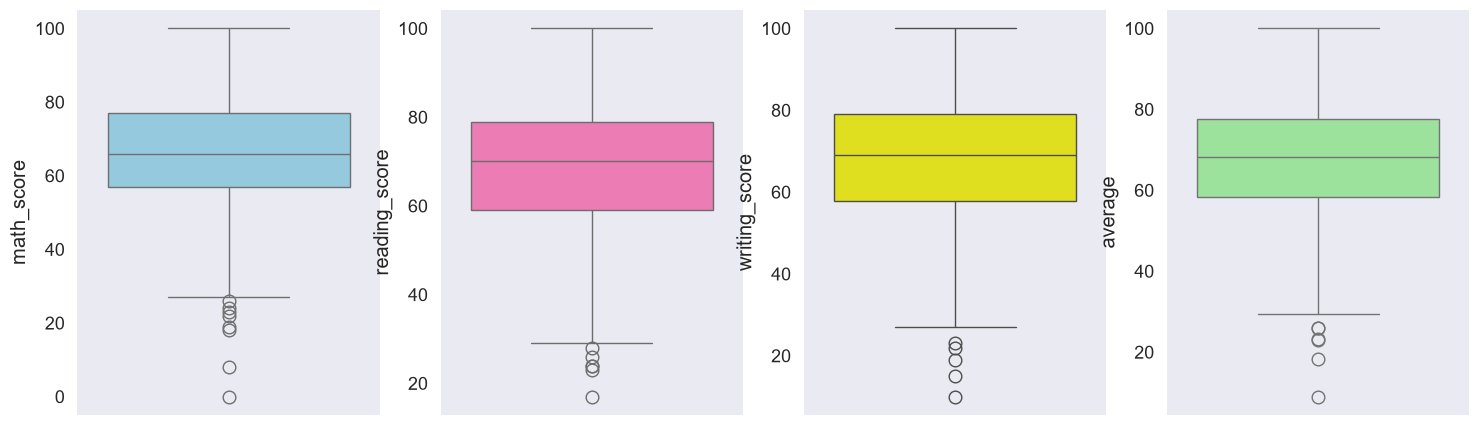

In [57]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

#### **4.4.7 MULTIVARIATE ANALYSIS**

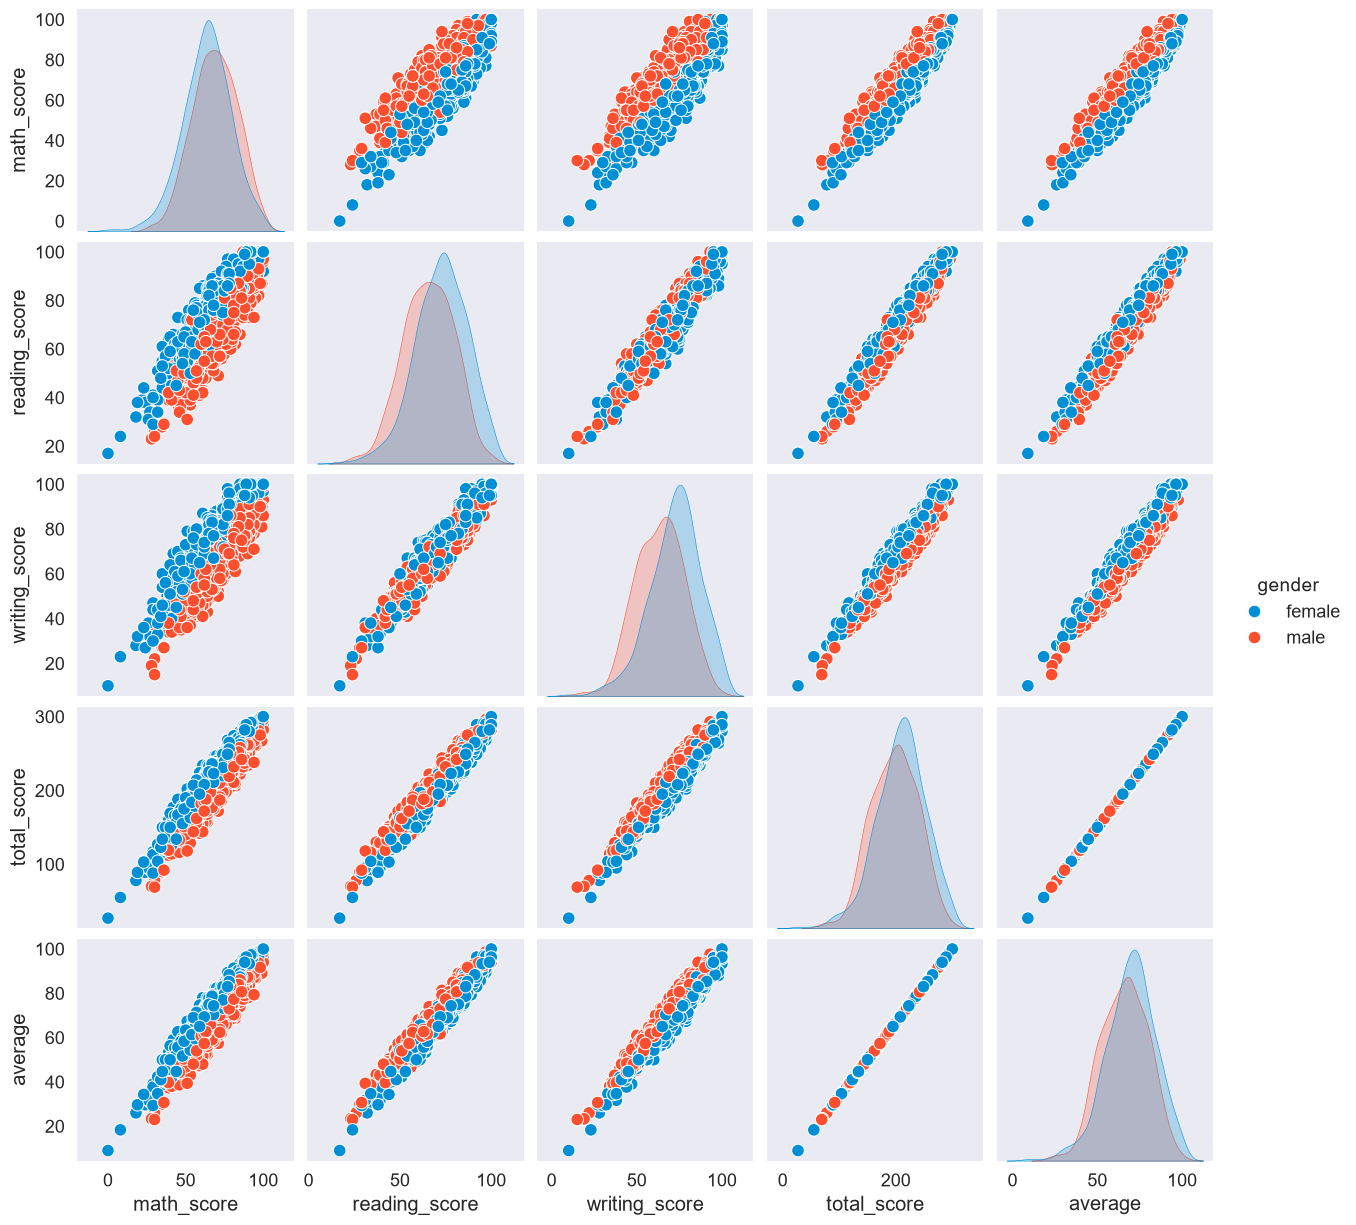

In [58]:

sns.pairplot(df,hue = 'gender')
plt.show()

#### **Insights**
##### • From the above plot it is clear that all the scores increase linearly with each other.

#### **5. CONCLUSION**
##### Student's Performance is related with lunch, race, parental level education
##### Females lead in pass percentage and also are top-scorers
##### Student's Performance is not much related with test preparation course
##### Finishing preparation course is benefitial.